##Assignment No. 2
### Multivariate Linear Regression
### Learn AI/ML
### Track 2 - Module 3 - Machine Learning



---



1. Import Neccessary Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

2. Load Dataset

In [ ]:
insurance = pd.read_csv('insurance.csv')

In [ ]:
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


array([[<Axes: title={'center': 'charges'}>]], dtype=object)

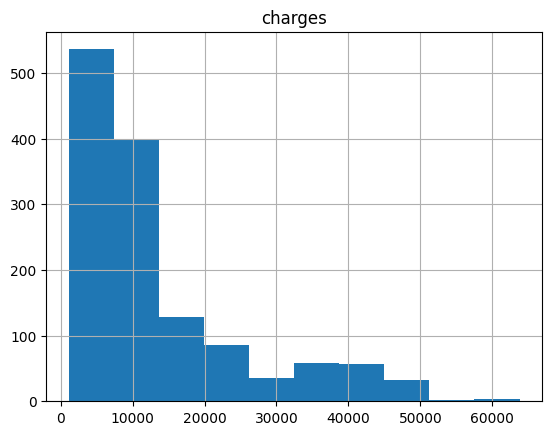

In [ ]:
# Plot histogram to check the distribution
insurance.hist(['charges'])

In [ ]:
# Log-transform charges (base 2) to reduce right-skewness and handle extreme outliers
# Create a column named 'log_charges'
insurance['log_charges'] = np.log2(insurance['charges'])

In [ ]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges,log_charges
0,19,female,27.900,0,yes,southwest,16884.92400,14.043448
1,18,male,33.770,1,no,southeast,1725.55230,10.752842
2,28,male,33.000,3,no,southeast,4449.46200,12.119415
3,33,male,22.705,0,no,northwest,21984.47061,14.424197
4,32,male,28.880,0,no,northwest,3866.85520,11.916945


array([[<Axes: title={'center': 'log_charges'}>]], dtype=object)

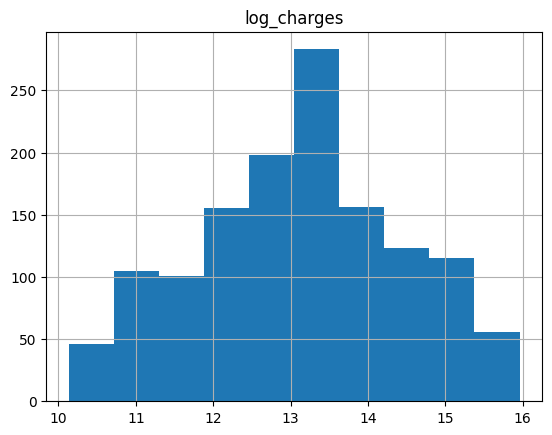

In [ ]:
# Plot histogram to check the distribution of log_charges
insurance.hist(['log_charges'])

In [ ]:
# Isolate numeric columns
numeric_data = insurance.select_dtypes(np.number)

In [ ]:
numeric_data

,age,bmi,children,charges,log_charges
0,19,27.900,0,16884.92400,14.043448
1,18,33.770,1,1725.55230,10.752842
2,28,33.000,3,4449.46200,12.119415
3,33,22.705,0,21984.47061,14.424197
4,32,28.880,0,3866.85520,11.916945
...,...,...,...,...,...
1333,50,30.970,3,10600.54830,13.371851
1334,18,31.920,0,2205.98080,11.107205
1335,18,36.850,0,1629.83350,10.670509
1336,21,25.800,0,2007.94500,10.971504


3. Exploratory Data Analysis (EDA) & Feature Engineering

In [ ]:
# Compute pairwise correlation matrix to
# find linear relationships between numeric variables
corr = numeric_data.corr()

In [ ]:
corr

,age,bmi,children,charges,log_charges
age,1.000000,0.109272,0.042469,0.299008,0.527834
bmi,0.109272,1.000000,0.012759,0.198341,0.132669
children,0.042469,0.012759,1.000000,0.067998,0.161336
charges,0.299008,0.198341,0.067998,1.000000,0.892964
log_charges,0.527834,0.132669,0.161336,0.892964,1.000000


In [ ]:
# Isolate the correlation of all numeric features specifically with the target variable
corr['log_charges']

,log_charges
age,0.527834
bmi,0.132669
children,0.161336
charges,0.892964
log_charges,1.000000


In [ ]:
corr['charges']

,charges
age,0.299008
bmi,0.198341
children,0.067998
charges,1.000000
log_charges,0.892964


In [ ]:
# Define the independent variables (features) to be used in the model
predictor = ['age','bmi']

In [ ]:
# Isolate categorical columns
cat_data = insurance.select_dtypes('O')

In [ ]:
cat_data

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest
...,...,...,...
1333,male,no,northwest
1334,female,no,northeast
1335,female,no,southeast
1336,female,no,southwest


<Axes: title={'center': 'log_charges'}, xlabel='sex'>

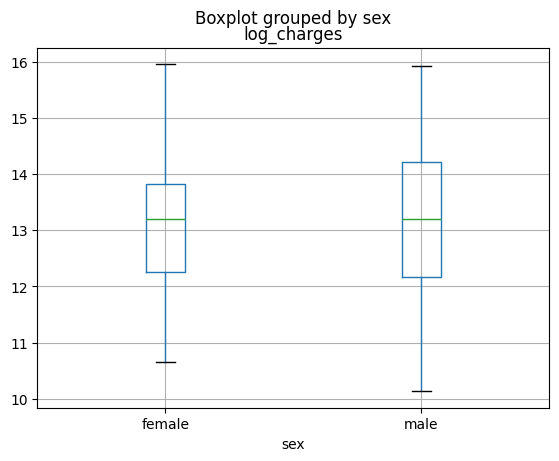

In [ ]:
# Box plot grouped by gender
insurance.boxplot('log_charges', by='sex')

<Axes: title={'center': 'log_charges'}, xlabel='smoker'>

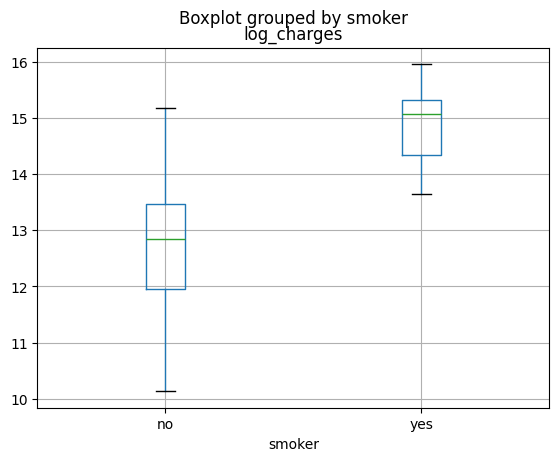

In [ ]:
# Box plot grouped by smoker
insurance.boxplot('log_charges', by='smoker')

<Axes: title={'center': 'log_charges'}, xlabel='region'>

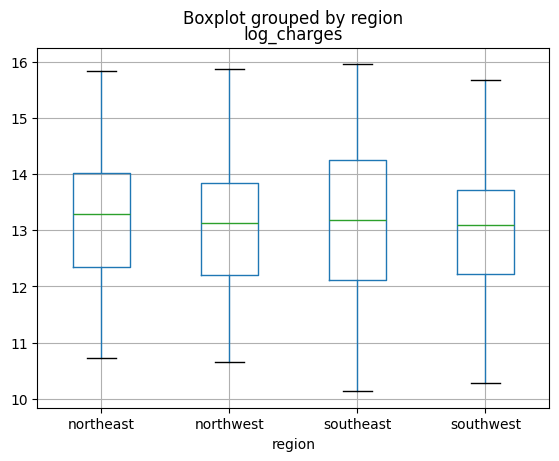

In [ ]:
# Box plot grouped by Region
insurance.boxplot('log_charges', by='region')

In [ ]:
insurance['smoker']

,smoker
0,yes
1,no
2,no
3,no
4,no
...,...
1333,no
1334,no
1335,no
1336,no


In [ ]:
# Conversion of yes or category to boolean
insurance['smoker'] =='yes'

,smoker
0,True
1,False
2,False
3,False
4,False
...,...
1333,False
1334,False
1335,False
1336,False


In [ ]:
# Add a column of boolean "is_smoker"
insurance['is_smoker'] = insurance['smoker'] =='yes'

In [ ]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges,log_charges,is_smoker
0,19,female,27.900,0,yes,southwest,16884.92400,14.043448,True
1,18,male,33.770,1,no,southeast,1725.55230,10.752842,False
2,28,male,33.000,3,no,southeast,4449.46200,12.119415,False
3,33,male,22.705,0,no,northwest,21984.47061,14.424197,False
4,32,male,28.880,0,no,northwest,3866.85520,11.916945,False


In [ ]:
predictor

['age', 'bmi']

In [ ]:
# Add 'is_smoker' to independent variables (features) to be used in the model
predictor.append('is_smoker')


In [ ]:
predictor

['age', 'bmi', 'is_smoker']

- charges = m1 x Age + m2 x bmi + m3 x is_smoker + b      # y = mx + b
- y       = weights + bias  # y = wx + b

4. Training Data Preparation

In [ ]:
# Create the (X) containing only the selected predictor variables
X = insurance[predictor]

In [ ]:
X

,age,bmi,is_smoker
0,19,27.900,True
1,18,33.770,False
2,28,33.000,False
3,33,22.705,False
4,32,28.880,False
...,...,...,...
1333,50,30.970,False
1334,18,31.920,False
1335,18,36.850,False
1336,21,25.800,False


In [ ]:
# Define the target (y) using the log-transformed insurance charges
y = insurance['log_charges']

In [ ]:
y

,log_charges
0,14.043448
1,10.752842
2,12.119415
3,14.424197
4,11.916945
...,...
1333,13.371851
1334,11.107205
1335,10.670509
1336,10.971504


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=1)

5. Model Implementation & Training

In [ ]:
insurance_model = LinearRegression()

In [ ]:
insurance_model.fit(X_train, y_train) # model training

LinearRegression()

- charges = m1 x Age + m2 x bmi + m3 x is_smoker + b      # y = mx + b
- y       = weights + bias  # y = wx + b

In [ ]:
# Extract the learned coefficients (weights) to
# see the impact of each feature on log_charges
insurance_model.coef_

array([0.04892865, 0.01523672, 2.23063344])

In [ ]:
# Extract the model intercept
insurance_model.intercept_

np.float64(10.293741356673163)

- **log_charges = m1 x Age + m2 x bmi + m3 x is_smoker + b**
- y = 0.04892865 * (age) +  0.01523672 * (bmi) + 2.23063344 * (is_smoker) + 10.293741356673163

6. Predictive Analysis & Performance Evaluation

In [ ]:
# Generate predictions on the training data to evaluate model fit and training error
y_predict_train = insurance_model.predict(X_train)

In [ ]:
# Generate predictions on the test data to
# evaluate real-world performance and generalization
y_predict_test = insurance_model.predict(X_test)

In [ ]:
mse_train = mean_squared_error(y_train, y_predict_train) # mean squred error
mse_test = mean_squared_error(y_test, y_predict_test)

In [ ]:
mse_train

0.4546665339270644

In [ ]:
mse_test

0.4355350875308211

In [ ]:
r2_score_train = r2_score(y_train, y_predict_train)
r2_score_test = r2_score(y_test, y_predict_test)

In [ ]:
r2_score_train

0.7421118855283421

In [ ]:
r2_score_test

0.7502277830580025

In [ ]:
# Calculate training residuals (prediction errors)
# to evaluate model performance and assumptions
residual = y_train - y_predict_train

In [ ]:
residual

,log_charges
1043,-0.430478
968,-0.034090
594,-0.434182
1079,-0.000986
1051,-0.014341
...,...
715,-0.101492
905,0.142984
1096,-0.106323
235,-0.573023


In [ ]:
residual.sum().round()

np.float64(0.0)

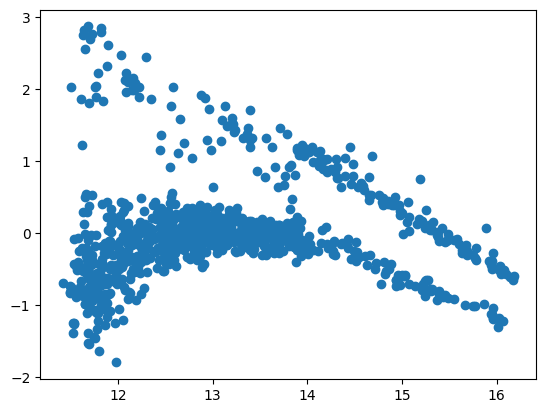

In [ ]:
# Scatter plot residuals against predicted values
plt.scatter(y_predict_train, residual)